# rENM Framework User Manual

John L. Schnase  
2026-04-27



# 1. Introduction

The **rENM framework** is a modular suite of R packages designed to
support the development and analysis of *retrospective ecological niche
models (rENMs)*. *Retrospective ecological niche modeling* integrates
historical species occurrence records with time-matched environmental
data to reconstruct the **spatio-temporal dynamics** of species’
responses to changing environmental conditions. By revealing *long-term
patterns*, rENMs provide a **powerful observational lens** for
addressing biological questions and assessing both the *current and
future conservation status* of species.

Although this analytical approach is broadly applicable across taxa, the
current implementation of the **rENM framework** is designed to
investigate **climate-driven dynamics** in North American bird species.
The framework spans approximately *45 years (1980–2020)*, leveraging
citizen science observations from the Cornell Lab of Ornithology’s eBird
database alongside environmental data derived from *NASA Earth system
models*.

Additional information can be found in the following publications and
the project’s GitHub repository at: <https://github.com/rENM-Framework>.

------------------------------------------------------------------------

**Selected Publications**

Schnase, J.L., M.L. Carroll, R.L. Gill, G.S. Tamkin, J. Li, S.L. Strong,
T.P. Maxwell, M.E. Aronne, and C.S. Spradlin. Toward a Monte Carlo
approach to selecting climate variables in MaxEnt. PLoS One. 2021. Mar
3;16(3):e0237208.
[doi:10.1371/journal.pone.0237208](https://doi.org/10.1371/journal.pone.0237208).
PMID: 33657125; PMCID: PMC7928495.

Schnase, J.L. and Carroll, M.L. 2022. Automatic variable selection inf
ecological niche modeling: a case study using Cassin’s Sparrow (*Peucaea
cassinii*). PLoS One. 2022 Jan 21;17(1):e0257502. [doi:
10.1371/journal.pone.0257502](https://doi.org/10.1371/journal.pone.0257502).
PMID: 35061658; PMCID: PMC8782318.

Schnase, J.L., and M.L. Carroll. 2023. “The MMX Toolkit:
High-Performance, Reanalysis-Based Climatic Suitability Modeling to
Advance Avian Conservation.” In Proceedings of the 2023 Conference on
Big Data from Space (BiDS’23): 6-9 November 2023, edited by P. Soille,
S. Lumnitz, and S. Albani, 299–303. Austrian Center, Vienna:
Publications Office of the European. <https://doi.org/10.2760/46796.>

Schnase, J. L., M. L. Carroll, P. M. Montesano, and V. A. Seamster.
2024. Complex changes in climatic suitability for Cassin’s Sparrow
(*Peucaea cassinii*) revealed by retrospective ecological niche
modeling. Journal of Field Ornithology 95(1):9.
<https://doi.org/10.5751/JFO-00432-950109>

Schnase, J. L., M. L. Carroll, P. M. Montesano, and V. A. Seamster.
2025. Shifts in breeding phenology for Cassin’s Sparrow (*Peucaea
cassinii*) over four decades. Journal of Field Ornithology 96(3):3.
<https://doi.org/10.5751/JFO-00691-960303>

Schnase, J. L., M. L. Carroll, P. M. Montesano, and V. A. Seamster.
2026. Shifts in seasonal climatic suitability for Cassin’s Sparrow
(*Peucaea cassinii*) over four decades. The Southwestern Naturalist,
70(1):1-17. <https://doi.org/10.1894/0038-4909-70.1.7>

------------------------------------------------------------------------

This manual guides users through the **rENM modeling and analysis
workflow**. Detailed documentation for individual functions is available
within the *respective package manuals*.

The **rENM framework** is an *active research platform* under ongoing
development. It is provided for *educational and research purposes only*
and is distributed **without formal technical support**. Feedback and
contributions are welcome.

Thank you for your interest.

**John Schnase**  
rENM.Framework@gmail.com



# 2. The rENM Workflow

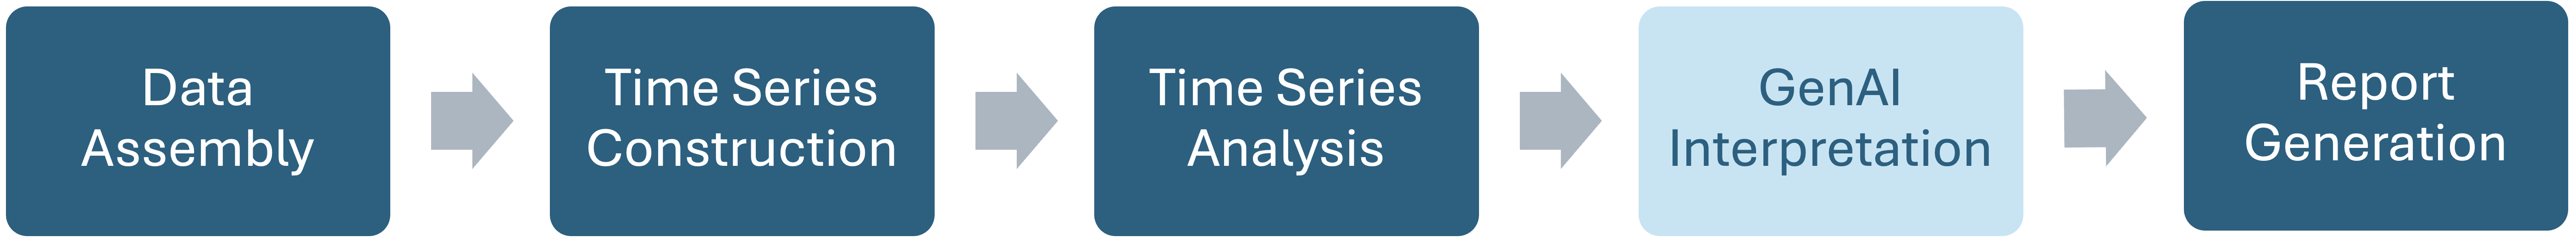

The **rENM processing pipeline** consists of **five core steps**,
including an *optional, experimental GenAI-mediated interpretation
step*. One way to engage this workflow is by using this **Quarto
Markdown (.qmd) document** as an *interactive User Manual*. It becomes a
**reproducible, executable scientific document** that combines *code,
results,* and *narrative* into a single, renderable file.

## 2.1 **Using the Quarto document**

- After initially configuring your local [host
  environment](#hostenvironment) and [RStudio
  environment](#hostenvironment), you can set the species [banding
  code](#bandingcode) and step through each of the following
  explanations and code blocks in sequence to perform the processing
  steps in the **rENM workflow**.

- Alternatively, from the *RStudio* **Run** drop-down menu, select
  *Restart R and Run All Chunks*. This performs an **automatic batch
  execution** of the workflow.

- Finally, you may wish to copy the *user-manual.qmd* file, rename it,
  and use it as a **customized, reproducible analysis template** for
  your own species or study system.

## 2.2 **Automated scripting**

Another option is to use the rENM.R script available in the rENM.scripts
package at <https://github.com/rENM-Framework/rENM-scripts>. Down load
the script and run the entire processing pipeline from the RStudio
console by providing a four-letter banding code, something like this:
rENM(“CASP”).

## 2.3 **Document rendering options**

Keep in mind that if you do use the *user-manual.qmd* file as a template
for your own species or study system, RStudio provides several rendering
options. From the **Render** drop-down menu, you can create .docx, .pdf,
.html, and .ipynb Jupyter Notebook versions of your new document.



# 3. Configuring the Host Environment

The most straightforward way to configure your local computing
environment is to complete the initial setup steps in a terminal window.
The examples provided here assume a macOS environment using the Bash
shell, which is the system I use.

The rENM framework relies on a simple, standardized filesystem
structure. At the top level is a base project directory. Within this
directory, a `data` subdirectory stores input datasets, including
species occurrence records and environmental predictor variables. In
this initial setup, you will install an example dataset and create a
symbolic link that points to this sample collection.

Model outputs and analysis results are written to a `runs` subdirectory
within the project directory, providing a clear and reproducible
organization for all rENM analyses.

PROJECT_DIRECTORY/  
\|\_\_\_ data -\> (symbolic link to example_data)  
\|\_\_\_ example_data/…  
\|\_\_\_ runs/…

You only need to configure your host environment once. After completing
this initial setup, you can move into the RStudio environment to
finalize the rENM framework installation and begin your analyses.

In the examples that follow, I use `~/rENMtest` as the project directory
for illustration. In practice, you should choose a directory name that
fits your own workflow. For example, I typically use `~/rENM` in my own
work. If you’d prefer to run these script outside of the RStudio
ecosystem, they’re available in the GitHub repository at
<https://github.com/rENM-Framework/rENM-scripts>.

## 3.1 Creating the project directory

You’ll first need to create the base project directory and the `runs`
subdirectory. Open a terminal window and run the following commands:

``` bash
#!/usr/bin/env bash

# set project directory name
PROJECT_DIRECTORY="$HOME/rENMtest"

# create initial directory structure
mkdir -p "$PROJECT_DIRECTORY"
mkdir -p "$PROJECT_DIRECTORY/runs"
```

## 3.2 Installing the example data set

Next, you’ll want to install the example data set. Make sure your
current working directory is the project base directory you just
created, then run the following commands from a terminal window:

``` bash
#!/usr/bin/env bash

# set project directory name (same as above ...)
PROJECT_DIRECTORY="$HOME/rENMtest" 
cd ${PROJECT_DIRECTORY}

# download and unzip example data set
DATA_URL="https://storage.googleapis.com/renm_data/example_data.zip"
ZIP_FILE="example_data.zip"
curl -L -o "${ZIP_FILE}" "${DATA_URL}"
unzip -o "${ZIP_FILE}"

# create symbolic link
ln -sfn example_data data

# clean up the installation
rm -rf __MACOSX
rm -f "$ZIP_FILE"
```

# 4. Configuring the RStudio Environment

From this point forward, all work is performed in the RStudio
environment using R. Begin by specifying the location of the base
project directory you created during the previous setup steps. This
allows both RStudio and the rENM framework to locate and manage project
files consistently.

## 4.1 Setting the project directory location

The following command defines this location in the `.Renviron` file.
This step only needs to be completed once during the initial setup.
After running the command, I recommend that you leave it commented out
in future sessions. Be sure that the base directory specified in this
command matches the directory you created in the previous steps.

In [ ]:
# # set the location of the project directory
# write(
#   paste0('RENM_PROJECT_DIR="', file.path(Sys.getenv("HOME"), "rENMtest")),
#   file = "~/.Renviron",
#   append = TRUE
# )
# s
# # reload (or restart R)
# readRenviron("~/.Renviron")
# Sys.getenv("RENM_PROJECT_DIR")

## 4.2 Installing the framework packages

Next, install the rENM framework’s collection of modular packages. These
can be obtained directly from the project’s GitHub repository, as shown
below. The framework currently consists of six modules. This
installation step only needs to be completed once.

In [ ]:
# # install rENM framework packates from the GitHub repository
# install.packages("devtools")
# devtools::install_github("rENM-Framework/rENM.core")
# devtools::install_github("rENM-Framework/rENM.data")
# devtools::install_github("rENM-Framework/rENM.model")
# devtools::install_github("rENM-Framework/rENM.analysis")
# devtools::install_github("rENM-Framework/rENM.reports")
# devtools::install_github("rENM-Framework/rENM.ai")

## 4.3 Loading the rENM framework modules

Now, load the installed rENM framework packages.

In [ ]:
# load the installed rENM framework packages
library(rENM.core)
library(rENM.data)
library(rENM.model)
library(rENM.analysis)
library(rENM.ai)
library(rENM.reports)

# 5. Performing an rENM Analysis

Species within the rENM framework are identified using a four-character
banding code (alpha code). To demonstrate the framework’s capabilities,
the example dataset includes three species: Brown-capped Rosy-Finch
(*Leucosticte australis*; BCRF), Cassin’s Sparrow (*Peucaea cassinii*;
CASP), and Greater Roadrunner (*Geococcyx californianus*; GRRO). These
species represent a range of ecological contexts, providing examples of
small, medium, and large geographic distributions, as well as varying
occurrence record densities.

## 5.1 Viewing installed species data

Use the `show_species()` helper function to display the full list of
species available in the framework’s example dataset. The four-letter
alpha code (`ALPHA.CODE`) is used to identify the species selected for
analysis in the next step.

In [ ]:
# show available species
rENM.core::show_species()

## 5.2 Setting the species banding code

In [ ]:
# set four-letter banding code of a bird species
alpha_code <- "BCRF"
# alpha_code <- "CASP"
# alpha_code <- "GRRO"

# 6. Data Assembly

## 6.1 Occurrence data

### - Gathering eBird records

The first step in an rENM time series analysis is to prepare the input
occurrence data and environmental variables. This begins with extracting
species-specific occurrence records from a downloaded eBird Basic
Dataset (EBD) text file located in the base data directory.

The function described below reads the raw EBD file, filters records
with valid geographic coordinates, and writes a cleaned CSV file to the
run directory. It then partitions the occurrence data into nine 5-year
temporal bins spanning 1980–2020.

Each temporal subset is saved as a separate CSV file in the run
directory under `<alpha_code>/_occs/tmp/` for use in subsequent
processing steps.

In [ ]:
# extract ebird occurrence records from the base collection
rENM.data::get_ebird_occurrences(alpha_code)

### - Removing duplicate records

Next, remove duplicate records from the occurrence files in the
`<alpha_code>/_occs/tmp/` run directory.

In [ ]:
# de-duplicate occurrence records
rENM.data::remove_duplicate_occurrences(alpha_code)

### - Spatial thinning

You may optionally apply spatial thinning to the occurrence records.
Thinning reduces spatial clustering by enforcing a minimum distance
between points, helping to mitigate sampling bias. For example, analyses
of Cassin’s Sparrow typically use a thinning distance of 8 km (~5 miles)
to reduce the likelihood of counting the same individual multiple times.
This step can be skipped entirely or configured by setting the
`thin_distance` parameter, as shown below.

Thinning can be time-consuming. By default, temporal bins are processed
sequentially. A parallel processing option is also available and can
reduce runtime; however, if system resources are limited or uncertain,
the default sequential approach is recommended. Comment out the option
you do not use.

In [ ]:
# set thinning distance (radius in km)
thin_distance <- 1 # default value

# thin records in the _occs/tmp/ run collection [sequential version]
# thin_occurrences(alpha_code, thin_distance)

# thin records in the _occs/tmp/ run collection [parallel version]
rENM.data::thin_occurrences2(alpha_code, thin_distance)

### - Limiting the record count

There may be times when you’d like to set an upper limit on the number
of occurrence records retained within each temporal bin. This can be
useful for reducing excessively high record densities, which may
negatively affect model performance. This step is optional.

In [ ]:
# set upper bound on the number of occurrence records
record_count <- 250

# thin records to upper bound
rENM.data::limit_record_count(alpha_code, record_count)

### - Wrapping up occurrence data prep

We finish setting up occurrence data by moving the prepared per-bin
occurrence files from the temporary *\<alpha_code\>/\_occs/tmp/*
directory into the main *\<alpha_code\>/\_occs/* directory for our
species run. After copying the files, the temporary directory is
removed. This is the finial cleanup step before preparing environmental
data.

In [ ]:
# move filtered records to the <alpha_code>/_occs/ run collection and tidy up
rENM.data::tidy_occurrences(alpha_code)

## 6.2 Environmental data

### - Setting the spatial extent

Preparing environmental data for modeling involves several steps, some
of which are optional. The first step is to define the spatial extent of
the analysis. This step is required.

The framework provides three options for specifying model extent:  
(1) derive extent from the species’ eBird occurrence records,  
(2) derive extent from the species’ USGS GAP range, or  
(3) define the extent manually.

Select the desired approach by commenting out the options you do not
intend to use. For guidance on manually specifying parameters, run
`?set_extent` in the RStudio console.

In [ ]:
# set model extent using the usgs gap range
rENM.data::find_range_extent(alpha_code)

# set model extent using ebird occurrences records
# rENM.data::find_occurrence_extent(alpha_code)

# manually set the model extent
# rENM.data::set_extent(alpha_code)

### - Assembling MERRA variables

We’re now ready to copy environmental variables from the base data
collection into the species-specific run directory. Begin by selecting
the MERRA-2 and/or MERRAclim-2 variables to include in the analysis. Use
the `show_variables()` utility in the RStudio console to display the
full list of available variables. Assign your selections to the
`m2_vars` and `mc_vars` parameters, as shown below. Setting either
parameter to `NULL` will include all available variables of that type.
The example dataset includes the variables used in Schnase et
al. (2026), described above. Additional details are provided in the
package documentation.

In [ ]:
# MERRA-2 microclimatic variables
# m2_vars = c("evpintr", "evpsoil", "prevtot", "qv2m",
#             "speed", "swgnt", "tautot")

# MERRAclim-2 macroclimatic variables
# mc_vars = c("bio3", "bio5", "bio8", "bio13",
#             "bio14", "bio15", "bio18")

Once variables are selected, the extraction step copies them from the
base collection, crops each layer to the defined spatial extent, and
writes the results to the run directory under `<alpha_code>/_vars/` for
subsequent processing.

In [ ]:
# extract merra variables and move to the run directory
rENM.data::get_merra_variables(
  alpha_code = alpha_code,
  m2_vars = NULL,
  mc_vars = NULL)

# 7. Time Series Construction

## 7.1 Staging occurrence records

With input data prepared, the next step is to construct the rENM time
series. This begins by moving the processed occurrence records from the
`<alpha_code>/_occs/` directory into a structured time series directory.

The function described below creates a `TimeSeries` directory and
organizes it into nine 5-year bins labeled by year (1980–2020). Within
each bin, occurrence records are stored in an `occs` subdirectory. The
resulting structure is: `<alpha_code>/TimeSeries/<year>/occs/` .This
organization becomes clear after running the function and inspecting the
resulting `TimeSeries` directory.

In [ ]:
# move prepared occurrence files from the <alpha_code>/_occs/ directory 
#   to 5-year bins within the <alpha_code/TimeSeries/occs/ directory
rENM.model::stage_occurrences(alpha_code)

## 7.2 Staging environmental variables

Environmental variables are now staged for time series analysis. Two
approaches are available; select only one.

### - Option 1 - Simple staging

This function performs simple staging by transferring all cropped
environmental predictors from the `<alpha_code>/_vars/` directory to the
`TimeSeries` directory without modification. Files are organized into a
`vars` subdirectory within each temporal bin created in the previous
step. The resulting structure is: `<alpha_code>/TimeSeries/<year>/vars/`
where `<year>` spans 1980–2020 in 5-year increments.

In [ ]:
# move all the cropped environmental variables from the <alpha_code>/_vars/
#  directory to 5-year bins within the <alpha_code/TimeSeries/vars/ directory
# rENM.model::stage_all_variables(alpha_code)

### - Option 2 - Staging with down selection

With this option, a Monte Carlo–based variable selection procedure
(Schnase et al. 2022) is first applied to the variables in
`<alpha_code>/_vars/`. This step identifies the highest-performing
variables, which are then transferred to the `TimeSeries` directory for
further processing.

In [ ]:
# down select variables (maxent version)
# rENM.model::screen_by_convergence1(alpha_code)

# down select variables (maxnet version)
rENM.model::screen_by_convergence2(alpha_code)

In [ ]:
# move the down selected, cropped environmental variables from the 
#  the <alpha_code>/_vars/ directory to 5-year bins within the 
#  <alpha_code/TimeSeries/vars/ directory
rENM.model::stage_screened_variables(alpha_code)

## 7.3 Reducing covariance

This optional step reduces covariance among the staged environmental
variables, records the results, and retains a subset of non-collinear
predictors for further processing. By default, a “light-touch” approach
is applied using variance inflation factors (VIF) and pairwise
correlation thresholds. A relaxed VIF threshold (10) and a high
correlation threshold (0.95) are used to remove only strongly redundant
variables while preserving alternative representations of environmental
gradients. This helps maintain the key dimensions of environmental
structure identified during earlier screening steps. In practice,
improved representation of environmental structure may be achieved by
omitting this step.

In [ ]:
# reduce covariance among staged variables
# rENM.model::reduce_covariance(alpha_code)

## 7.4 Computing the time series

With occurrence records and environmental variables staged, the next
step is to generate a time series of ensemble models. The
`create_timeseries()` function orchestrates this process by making
parallel calls to `create_ensemble_model()` to build models for each
temporal bin. By default, ensemble predictions are computed as the
unweighted average of five model types: `maxnet`, random forest (`rf`),
boosted regression trees (`brt`), generalized linear models (`glm`), and
multivariate adaptive regression splines (`mars`). For additional
details and configuration options, refer to the documentation by running
`?create_ensemble_model` in the RStudio console.

In [ ]:
# create an rENM time series
rENM.model::create_timeseries(alpha_code)

# 8. Time Series Analysis

## 8.1 Suitability trend analysis

### - Finding the suitability trend

This required step computes per-cell Theil–Sen trend estimates from the
time series of predicted suitability rasters and derives Mann–Kendall
statistics (p-values and Z-scores) to assess temporal trends in climatic
suitability. The resulting trend raster serves as the foundation for
subsequent analyses.

In [ ]:
# compute the thiel-sen trend across the time series
rENM.analysis::find_suitability_trend(alpha_code)

### - Finding overall trend percentages

This is the first of several different ways of studying the suitability
trends that we’ve derived from our rENM time series. This step provides
an initial summary of the suitability trends derived from the rENM time
series. The function below computes cell-wise trend sign statistics from
the suitability trend raster and summarizes the proportions of positive,
negative, and neutral (zero) trends *across the full modeled extent.*

In [ ]:
# find proportions of pos, neg, and zero values across modeled extent
rENM.analysis::find_trend_percentages(alpha_code)

### - Finding range trend percentages

The function below computes cell-wise trend sign statistics from the
suitability trend raster and summarizes the proportions of positive,
negative, and neutral (zero) trends *within the species’ USGS GAP
range.*

In [ ]:
# find proportions of pos, neg, and zero values across USGS GAP range
rENM.analysis::find_range_change_percentages(alpha_code)

### - Finding state-level suitability trends

We can now perform a state-level analysis of climatic suitability trends
based on the species’ USGS GAP range. The function below computes
summary metrics for each state intersecting the GAP range and generates
a map illustrating spatial patterns alongside state-level statistics.

In [ ]:
# create state-level suitability trend analysis and map for a species
rENM.analysis::create_state_trend_analysis(alpha_code)

## 8.2 Centroid trend analysis

### - Finding temporal trends

Another approach to analyzing climatic suitability trends is to examine
spatial shifts in the weighted centroid of suitability over time. This
function fits Bayesian linear models to annual centroid coordinates
(latitude and longitude) and writes the resulting plots and summary
statistics to the species’ run directory.

In [ ]:
# analyze temporal trends in suitability centroids
rENM.analysis::analyze_weighted_centroids(alpha_code)

### - Finding bioclimatic velocity

Historical centroid trajectories can also be used to quantify the
direction, distance, and velocity of suitability shifts. This step
computes these metrics and writes the results to the species’ run
directory.

In [ ]:
# finds bioclimatic verlocity from weighted centroids
rENM.analysis::find_bioclimatic_velocity(alpha_code)

To support visualization of long-term shifts, this function generates a
suitability trend map with an overlay of the centroid displacement
vector. The resulting map is saved to the species’ run directory.

In [ ]:
# plot and save suitability trend map with centroids
rENM.analysis::save_trend_plot_with_centroids(alpha_code)

## 8.3 Variable trend analysis

### - Gathering ranked variables

This step consolidates ranked variable importance results across the
time series into a single summary dataset for the species. The output is
a unified CSV file that can be used for subsequent variable analysis.

In [ ]:
# gather variable rankings
rENM.analysis::gather_variable_contributions(alpha_code)

### - Summarizing variable contributions

Using this summary, this function selects variables based on average
relative contribution and generates a comprehensive set of
visualizations and summary statistics.

In [ ]:
# summarize variable contributions
rENM.analysis::summarize_variable_contributions(alpha_code)

## 8.4 Experimental metrics

### - Bioclimatic acceleration

The following function wraps *find_suitability_change_trend()* and
*plot_suitability_change_trend()* to generate a map highlighting areas
of accelerating and decelerating trends in climatic suitability. This
step is experimental but provides an additional perspective on the
spatial and temporal dynamics of historical climatic influences on
suitability.

In [ ]:
# create a climatic suitability trend acceleration/deceleration map
rENM.analysis::create_suitability_change_map(alpha_code)

### - Hot spot analysis

This metric identifies areas where climatic suitability is declining at
an increasing rate. The function generates a map highlighting these
regions. This analysis is exploratory and may provide insight into areas
of heightened vulnerability to climate change.

In [ ]:
# create a hot spot map
rENM.analysis::create_hot_spot_map(alpha_code)

# 9. Report Generation

The following functions compile key outputs from the preceding analysis
steps to generate summary maps, tables, and reports. Because these
functions depend on products created earlier in the workflow, all prior
steps must be completed before proceeding to summary and report
generation.

## 9.1 Assemble suitability results

In [ ]:
# gather time series suitability maps
rENM.reports::gather_suitability_maps(alpha_code)

# gather range maps
rENM.reports::gather_range_maps(alpha_code)

# gather suitability trend and hot spot stats
rENM.reports::gather_suitability_trend_stats(alpha_code)

# create a suitability trend summary table
rENM.reports::create_suitability_trend_summary_table(alpha_code)

# create a suitability time series summary page
rENM.reports::assemble_suitability_timeseries_page(alpha_code)

# create a range time series summary page
rENM.reports::assemble_range_timeseries_page(alpha_code)

# create a suitability trends, acceleration/decleration page
rENM.reports::assemble_suitability_trends_page(alpha_code)

# create a state trends and state hot spot page
rENM.reports::assemble_state_trends_page(alpha_code)

## 9.2 Assemble variable results

In [ ]:
# create variable trend summary table
rENM.reports::create_variable_trend_summary_table(alpha_code)

# create variable trends page
rENM.reports::assemble_variable_trends_page(alpha_code)

# gather trend and rate-of-change maps for the top 10 variables
rENM.reports::gather_top_variable_trend_maps(alpha_code)

# create summary page for the top 10 variables
rENM.reports::assemble_variable_trend_maps_page(alpha_code)

## 9.3 Assemble centroid results

In [ ]:
# create centroid trend summary table
rENM.reports::create_centroid_trend_summary_table(alpha_code)

# create a suitability trends with centroids page
rENM.reports::assemble_centroid_trends_page(alpha_code)

# 10. GenAI Analysis

## 10.1 Suitability trend analysis

This experimental module uses generative AI (GenAI) to support
suitability trend analysis. In the first step, the function assembles an
AI-ready package containing suitability trend rasters, summary tables,
species metadata, and a structured prompt. In the second step, the
package is submitted to ChatGPT (GPT-5.1) for analysis. Finally, the
generated results are compiled into a PDF document.

In [ ]:
# build a data package for submission to ChatGPT
rENM.ai::assemble_ai_package(alpha_code)

# submit the package using the OpenAI Reponses API
rENM.ai::submit_ai_package(alpha_code)

# render the returned .docx file into a .pdf file
rENM.ai::render_ai_docx(alpha_code)

# 11. Create Final Report

In [ ]:
# create a final report comprising all summary pages
rENM.reports::assemble_final_report(alpha_code)

# these are the default pages, edit as needed ...
# rENM.reports::assemble_final_report(alpha_code, 
#                                     pages = c("Suitability-Trend-Analysis",
#                                               "Suitability-Trends",
#                                               "State-Trends",
#                                               "Centroid-Trends",
#                                               "Suitability-TimeSeries",
#                                               "Range-TimeSeries",
#                                               "Variable-Trends",
#                                               "Variable-Trend-Maps1",
#                                               "Variable-Trend-Maps2"))

# 12. Automated Workflows

# 13. APPENDICES

## 13.1 Technical specifications

## 13.2 Data extensions

### - Adding new species

### - Adding new variables